In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Make sure src/ is importable from the notebook
import sys
sys.path.insert(0, "..")

from src.data.loaders import load_ecdc_data
from src.data.validators import validate_ecdc_data

# Consistent plot style across all cells
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

print("Imports OK")

Imports OK


## Load Data

In [5]:
import logging
logging.basicConfig(level=logging.WARNING)  # suppress INFO logs in notebook

df = load_ecdc_data("../data/raw/")
df = validate_ecdc_data(df)

print(f"Shape: {df.shape}")
df.head(10)

Shape: (6134, 8)


,Year,CountryCode,Country,Pathogen,Antibiotic,PctResistant,NumResistant,NumIsolates
0,2005,AT,Austria,Klebsiella pneumoniae,Carbapenems,0.000000,0.0,NaN
1,2005,BG,Bulgaria,Klebsiella pneumoniae,Carbapenems,0.000000,0.0,NaN
2,2005,CY,Cyprus,Klebsiella pneumoniae,Carbapenems,NaN,0.0,NaN
3,2005,CZ,Czechia,Klebsiella pneumoniae,Carbapenems,0.000000,0.0,NaN
4,2005,DE,Germany,Klebsiella pneumoniae,Carbapenems,1.960784,2.0,102.0
5,2005,EE,Estonia,Klebsiella pneumoniae,Carbapenems,0.000000,0.0,NaN
6,2005,EL,Greece,Klebsiella pneumoniae,Carbapenems,27.813713,215.0,773.0
7,2005,ES,Spain,Klebsiella pneumoniae,Carbapenems,0.000000,0.0,NaN
8,2005,FI,Finland,Klebsiella pneumoniae,Carbapenems,0.000000,0.0,NaN
9,2005,FR,France,Klebsiella pneumoniae,Carbapenems,0.132802,1.0,753.0


## Basic Overview

In [15]:
print("=== Dataset Overview ===")
print(f"Rows         : {len(df)}")
print(f"Countries    : {df['Country'].nunique()}")
print(f"Year range   : {df['Year'].min()} – {df['Year'].max()}")
print(f"Combinations : {df[['Pathogen','Antibiotic']].drop_duplicates().shape[0]}")

print("\n========= Pathogen-Antibiotic Combinations ==========")
print(df.groupby(["Pathogen", "Antibiotic"]).size().to_string())

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Overview ===
Rows         : 6134
Countries    : 31
Year range   : 2000 – 2024
Combinations : 10

========= Pathogen-Antibiotic Combinations ==========
Pathogen                Antibiotic            
Acinetobacter spp.      Carbapenems               367
Enterococcus faecium    Vancomycin                688
Escherichia coli        3rd gen cephalosporins    697
                        Carbapenems               656
                        Fluoroquinolones          697
Klebsiella pneumoniae   3rd gen cephalosporins    580
                        Carbapenems               572
                        Fluoroquinolones          581
Pseudomonas aeruginosa  Carbapenems               577
Staphylococcus aureus   Meticillin                719

=== Missing Values ===
Year              0
CountryCode       0
Country           0
Pathogen          0
Antibiotic        0
PctResistant    286
NumResistant      0
NumIsolates     901
dtype: int64


## Resistance levels vary widely by country

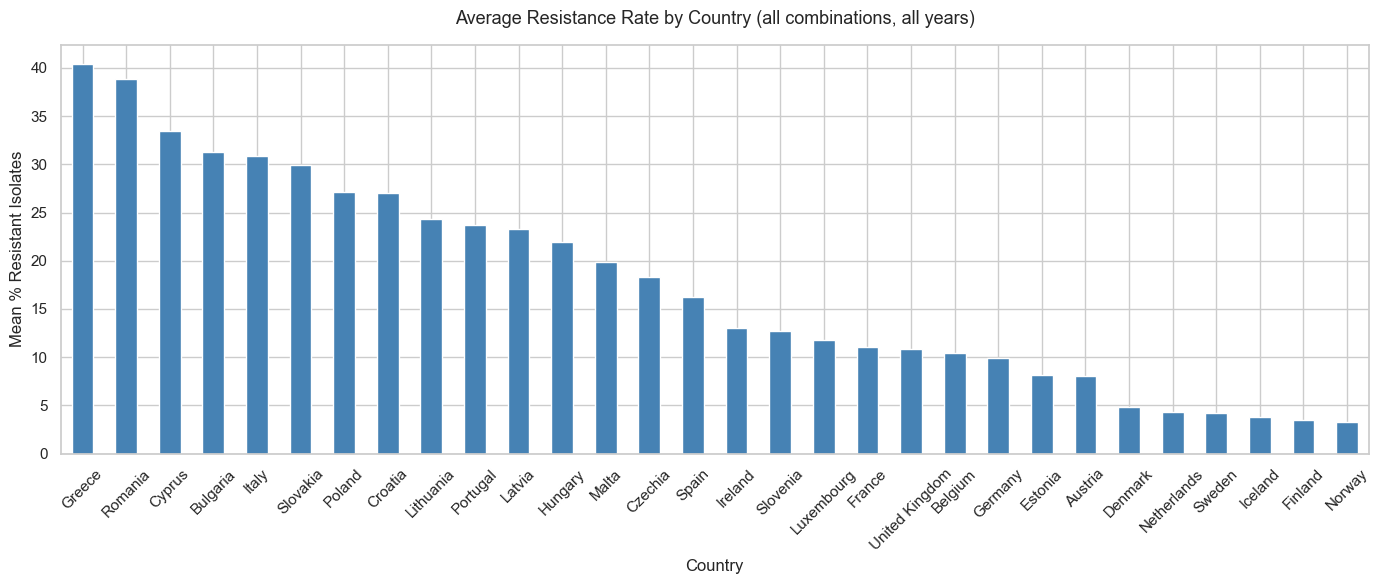


Top 5 highest resistance countries:
Country
Greece      40.365269
Romania     38.877182
Cyprus      33.421977
Bulgaria    31.281988
Italy       30.906398
Name: PctResistant, dtype: float64

Top 5 lowest resistance countries:
Country
Netherlands    4.272677
Sweden         4.263237
Iceland        3.748028
Finland        3.479208
Norway         3.330438
Name: PctResistant, dtype: float64


In [10]:
# Average PctResistant per country across all combinations and years
country_avg = (
    df.groupby("Country")["PctResistant"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
country_avg.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Average Resistance Rate by Country (all combinations, all years)", fontsize=13, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Mean % Resistant Isolates")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/01_resistance_by_country.png", dpi=150)
plt.show()

print("\nTop 5 highest resistance countries:")
print(country_avg.head())
print("\nTop 5 lowest resistance countries:")
print(country_avg.tail())

## Resistance trends over time

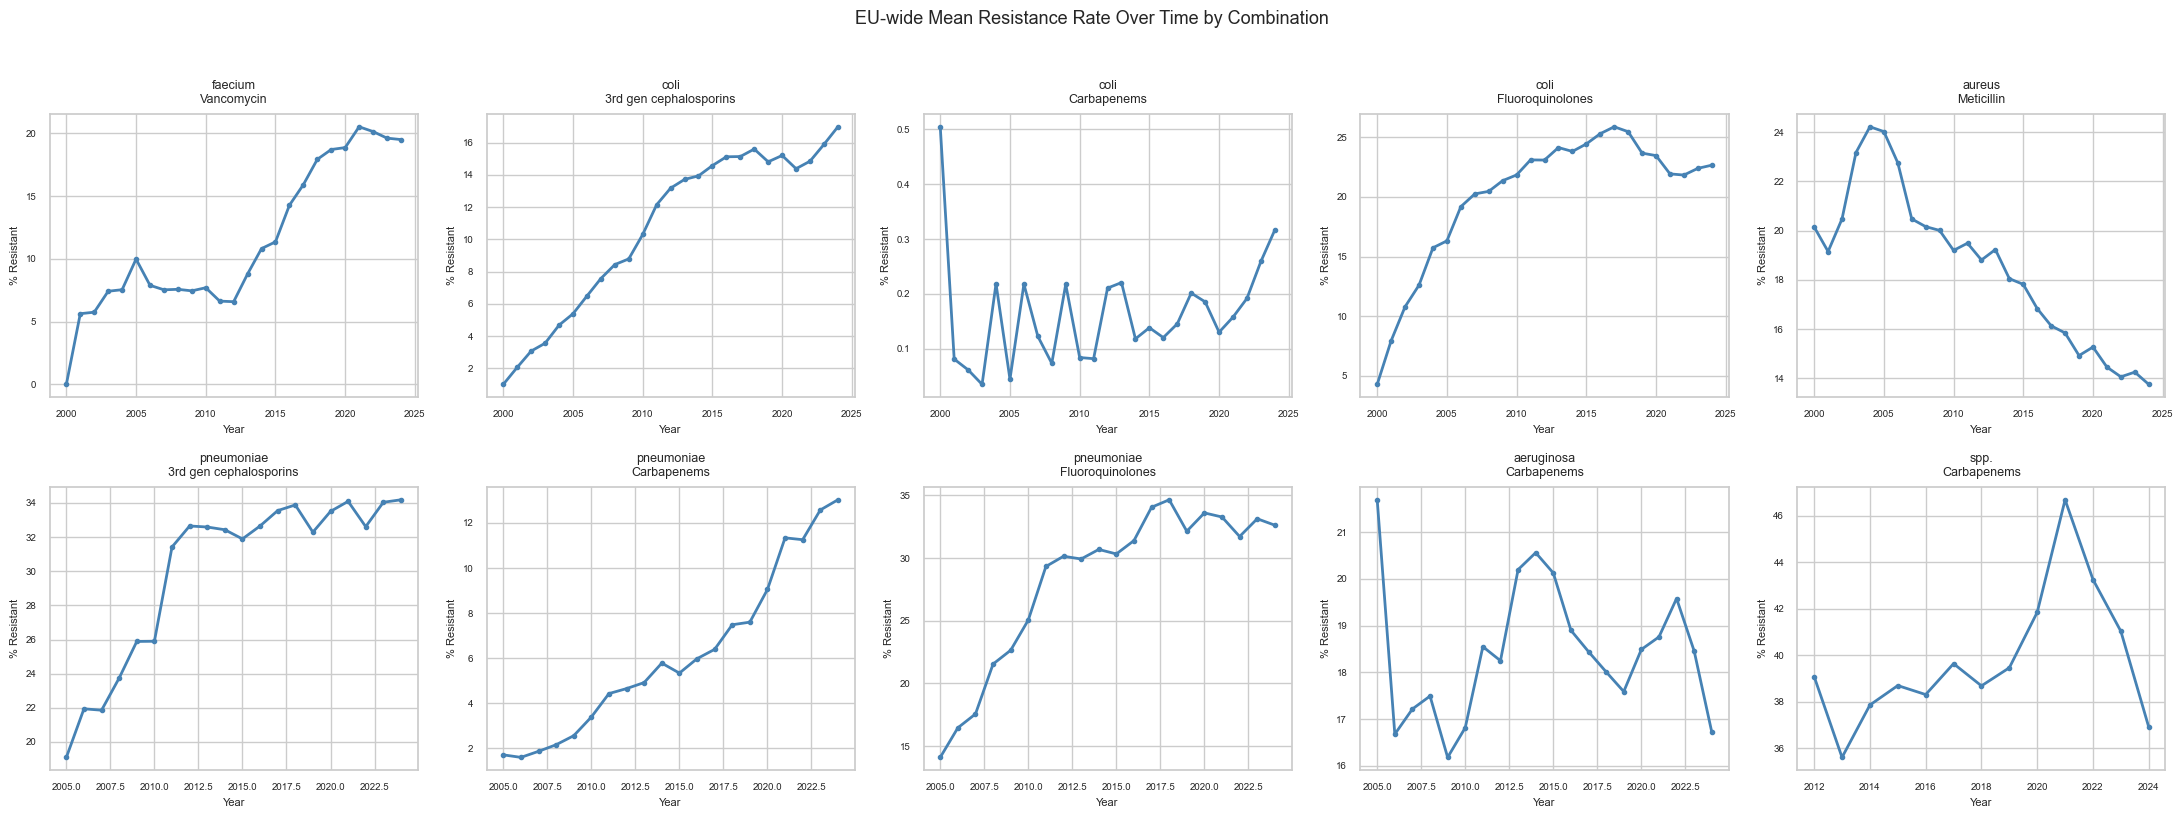

In [ ]:
# EU-wide average per year per combination
yearly = (
    df.groupby(["Year", "Pathogen", "Antibiotic"])["PctResistant"]
    .mean()
    .reset_index()
)

# Plot each combination as a separate line
combos = yearly[["Pathogen", "Antibiotic"]].drop_duplicates().values

fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=False)
axes = axes.flatten()

for i, (pathogen, antibiotic) in enumerate(combos):
    subset = yearly[
        (yearly["Pathogen"] == pathogen) & 
        (yearly["Antibiotic"] == antibiotic)
    ]
    axes[i].plot(subset["Year"], subset["PctResistant"], marker="o", markersize=3, linewidth=2, color="steelblue")
    axes[i].set_title(f"{pathogen.split()[-1]}\n{antibiotic}", fontsize=9, pad=8)
    axes[i].set_xlabel("Year", fontsize=8)
    axes[i].set_ylabel("% Resistant", fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle("EU-wide Mean Resistance Rate Over Time by Combination", 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/02_resistance_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## Spotting the most alarming combinations

In [12]:
# Which combinations have increased the most from their earliest year to latest?
def resistance_change(group):
    group = group.dropna(subset=["PctResistant"]).sort_values("Year")
    if len(group) < 5:
        return None
    earliest = group.iloc[:3]["PctResistant"].mean()
    latest   = group.iloc[-3:]["PctResistant"].mean()
    return latest - earliest

changes = (
    df.groupby(["Pathogen", "Antibiotic"])
    .apply(resistance_change)
    .dropna()
    .sort_values(ascending=False)
    .reset_index()
)
changes.columns = ["Pathogen", "Antibiotic", "ResistanceChange_pp"]

print("Combinations with LARGEST resistance increase (percentage points):")
print(changes.head(5).to_string(index=False))

print("\nCombinations with LARGEST resistance decrease:")
print(changes.tail(5).to_string(index=False))

Combinations with LARGEST resistance increase (percentage points):
              Pathogen             Antibiotic  ResistanceChange_pp
 Klebsiella pneumoniae 3rd gen cephalosporins            26.018723
 Klebsiella pneumoniae       Fluoroquinolones            23.262529
      Escherichia coli       Fluoroquinolones            18.554210
Pseudomonas aeruginosa            Carbapenems            17.061711
      Escherichia coli 3rd gen cephalosporins            16.894923

Combinations with LARGEST resistance decrease:
             Pathogen  Antibiotic  ResistanceChange_pp
 Enterococcus faecium  Vancomycin            14.773572
Klebsiella pneumoniae Carbapenems             7.108857
     Escherichia coli Carbapenems            -0.385809
Staphylococcus aureus  Meticillin           -11.680066
   Acinetobacter spp. Carbapenems           -11.747967


## Key EDA Findings

1. **Forecastable trends exist**: K. pneumoniae (3rd gen ceph, fluoroquinolones) and 
   E. faecium (vancomycin) show clear upward trends suitable for forecasting.

2. **Regime changes are present**: K. pneumoniae carbapenems was near-zero for a decade 
   then spiked after 2018. Standard trend features won't capture this — we need 
   change-point awareness in feature engineering.

3. **Success stories exist**: MRSA (S. aureus meticillin) is declining EU-wide. 
   The model must handle both directions.

4. **Some combinations are near-zero**: E. coli carbapenems has <0.5% resistance 
   throughout. Forecasting near-zero series is unreliable — we will flag these as 
   low-signal and interpret their forecasts cautiously.

5. **High country variance**: Southern/eastern European countries drive much of the 
   EU average upward. Country identity is a strong feature.

6. **Year-to-year noise**: Even smooth EU-wide trends have noisy individual country 
   series. Lag features and rolling averages will be essential to smooth this signal.

## Single country deep dive

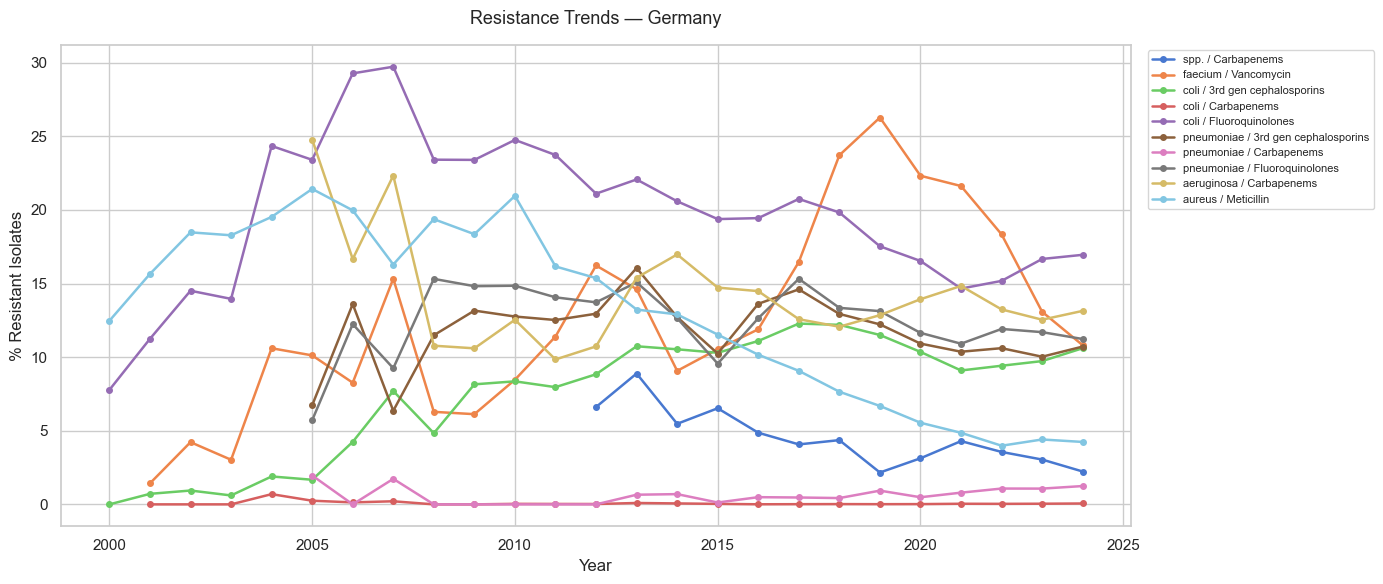

In [ ]:
COUNTRY = "Germany"  

subset = df[df["Country"] == COUNTRY].dropna(subset=["PctResistant"])

fig, ax = plt.subplots(figsize=(14, 6))

for (pathogen, antibiotic), group in subset.groupby(["Pathogen", "Antibiotic"]):
    group = group.sort_values("Year")
    label = f"{pathogen.split()[-1]} / {antibiotic}"
    ax.plot(group["Year"], group["PctResistant"], marker="o", markersize=4, linewidth=1.8, label=label)

ax.set_title(f"Resistance Trends — {COUNTRY}", fontsize=13, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("% Resistant Isolates")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"../reports/figures/03_country_deep_dive_{COUNTRY}.png", dpi=150, bbox_inches="tight")
plt.show()